In [2]:
import numpy as np
import os
import random
import matplotlib.image as mpimg
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.applications.mobilenet import MobileNet,preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Input,BatchNormalization,Dropout,GlobalAveragePooling2D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

In [3]:
test_data = "/kaggle/input/fruit-and-vegetable-image-recognition/test"
train_data = "/kaggle/input/fruit-and-vegetable-image-recognition/train"

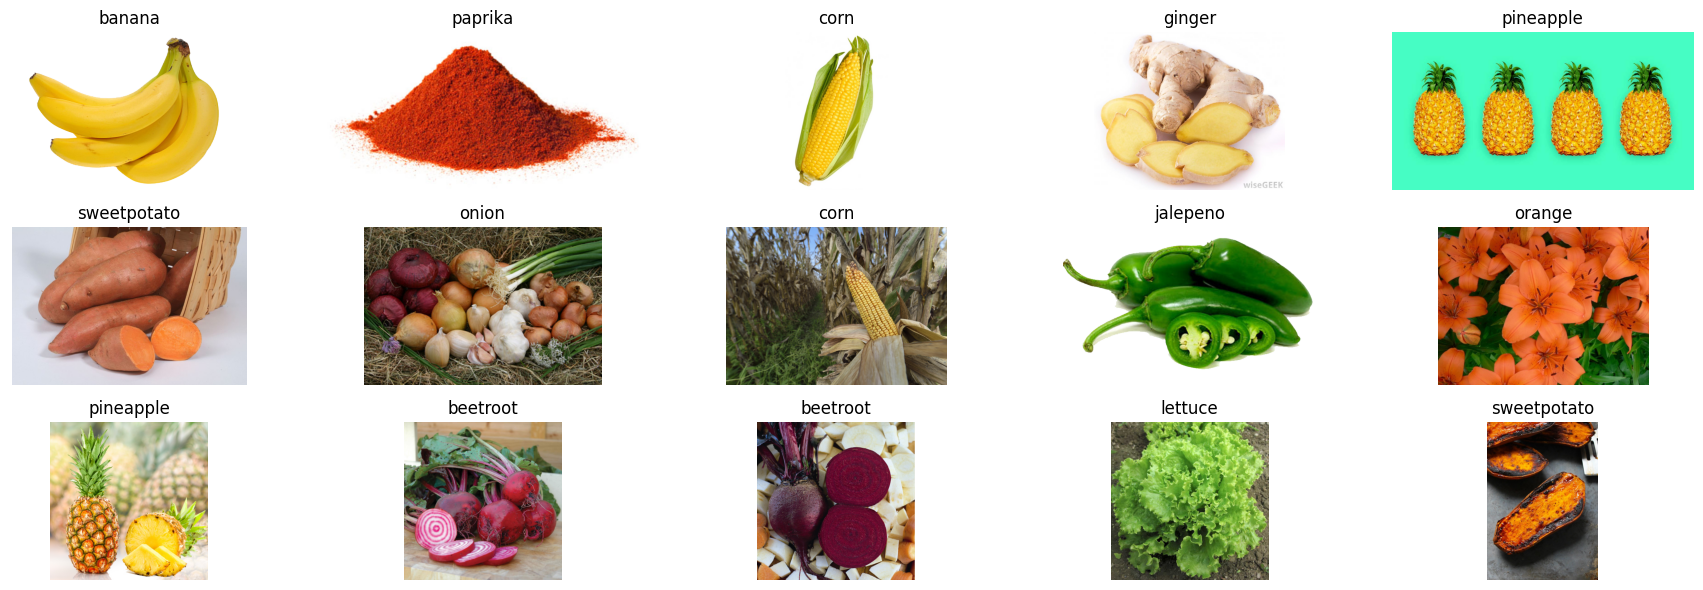

In [4]:
dataset_path = '/kaggle/input/fruit-and-vegetable-image-recognition/train'


class_names = os.listdir(dataset_path)


image_paths = []
labels = []

for class_name in class_names:
    class_path = os.path.join(dataset_path, class_name)
    for fname in os.listdir(class_path):
        image_paths.append(os.path.join(class_path, fname))
        labels.append(class_name)


# Combine paths and labels for shuffling
combined = list(zip(image_paths, labels))

# Select 15 random samples
random_samples = random.sample(combined, 15)


plt.figure(figsize=(18, 6))
for i, (img_path, label) in enumerate(random_samples):
    img = mpimg.imread(img_path)
    plt.subplot(3, 5, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(label)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [5]:
train_datagen = ImageDataGenerator(
    rescale=1.0/255,  # Normalize pixel values (0-1)
    
)

In [6]:
train_dataset = train_datagen.flow_from_directory(
    train_data,
    target_size=(224, 224),  # Resize all images
    batch_size=32,
    class_mode="binary",  
    subset="training"  # Use training split
)

Found 3115 images belonging to 36 classes.


In [7]:
test_datagen = ImageDataGenerator(rescale=1./255)  # Normalize pixel values

# Load test data from directory
test_dataset = test_datagen.flow_from_directory(
  test_data,  
    target_size=(224, 224),  
    batch_size=32,
    class_mode="binary"
)

Found 359 images belonging to 36 classes.


In [8]:
base_model = MobileNet(weights='imagenet', 
                      include_top=False, 
                      input_shape=(224, 224, 3),
                      alpha=1.0) 

I0000 00:00:1748261696.780438      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
for layer in base_model.layers:
    layer.trainable = False
# Add custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(36, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

In [10]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1 (Conv2D)                       │ (None, 112, 112, 32)        │             864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1_bn (BatchNormalization)        │ (None, 112, 112, 32)        │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1_relu (ReLU)                    │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_1 (DepthwiseConv2D)          │ (None, 112, 112, 32)        │             288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_1_bn (BatchNormalization)    │ (None, 112, 112, 32)        │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_1_relu (ReLU)                │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pw_1 (Conv2D)                   │ (None, 112, 112, 64)        │           2,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pw_1_bn (BatchNormalization)    │ (None, 112, 112, 64)        │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pw_1_relu (ReLU)                │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pad_2 (ZeroPadding2D)           │ (None, 113, 113, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_2 (DepthwiseConv2D)          │ (None, 56, 56, 64)          │             576 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_2_bn (BatchNormalization)    │ (None, 56, 56, 64)          │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_2_relu (ReLU)                │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pw_2 (Conv2D)                   │ (None, 56, 56, 128)         │           8,192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pw_2_bn (BatchNormalization)    │ (None, 56, 56, 128)         │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pw_2_relu (ReLU)                │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_3 (DepthwiseConv2D)          │ (None, 56, 56, 128)         │           1,152 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_3_bn (BatchNormalization)    │ (None, 56, 56, 128)         │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_3_relu (ReLU)                │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pw_3 (Conv2D)                   │ (None, 56, 56, 128)         │          16,384 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 4,821,732 (18.39 MB)

 Trainable params: 1,592,868 (6.08 MB)

 Non-trainable params: 3,228,864 (12.32 MB)

In [11]:
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [13]:
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5, min_lr=1e-5)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [16]:
history = model.fit(
                   train_dataset,
                    batch_size=128,
                    epochs=10,
                    validation_data=test_dataset,
                    callbacks = [lr_scheduler,early_stopping]
                    )

Epoch 1/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.1042 - loss: 3.4634 - val_accuracy: 0.6657 - val_loss: 1.9659 - learning_rate: 1.0000e-04
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 80s 820ms/step - accuracy: 0.3969 - loss: 2.2768 - val_accuracy: 0.7855 - val_loss: 0.9902 - learning_rate: 1.0000e-04
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 76s 780ms/step - accuracy: 0.5519 - loss: 1.6163 - val_accuracy: 0.8719 - val_loss: 0.5889 - learning_rate: 1.0000e-04
Epoch 4/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 79s 805ms/step - accuracy: 0.6485 - loss: 1.2370 - val_accuracy: 0.8942 - val_loss: 0.4521 - learning_rate: 1.0000e-04
Epoch 5/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 78s 797ms/step - accuracy: 0.7208 - loss: 1.0111 - val_accuracy: 0.9053 - val_loss: 0.3589 - learning_rate: 1.0000e-04
Epoch 6/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 76s 773ms/step - accuracy: 0.7250 - loss: 0.9335 - val_accuracy: 0.9220 - val_loss: 0.3072 - learning_rate: 1.0000e-04
Epoch 7/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 77s 783ms/step - accur

In [17]:
test_loss, test_acc = model.evaluate(test_dataset, verbose=0)
print(f'Test accuracy: {test_acc:.4f}')

Test accuracy: 0.9443


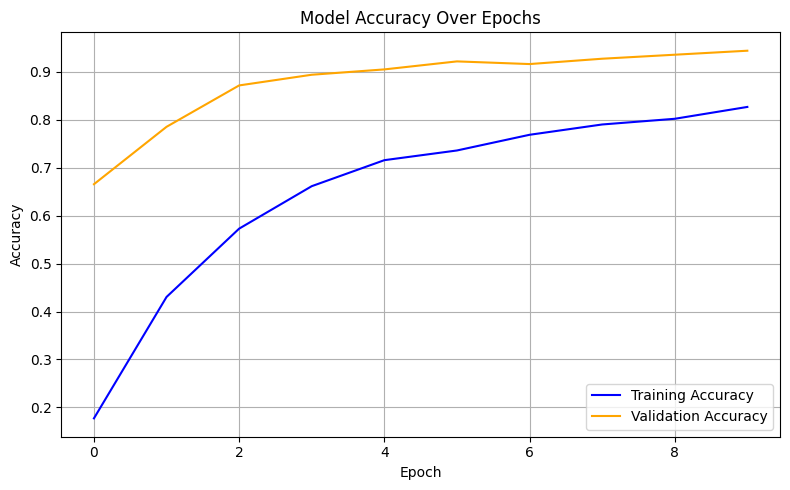

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()